In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [184]:
def _ISAUnitFR(session,regs=None,return_fr=False):

    R = fma.regions.regions(session,phases='sleep.*#0',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    sleep0 = R.eventIntervals('sleep.*#0')
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    if on.size == 0:
        return None

    # durations to compute firing rates
    sleep0_dur = np.diff(sleep0).sum()
    isa_dur = np.diff(isa).sum()
    on_dur = np.diff(on).sum()
    durations = [sleep0_dur-isa_dur, on_dur, isa_dur-on_dur]

    spikes = R.spikes(regs=regs)
    cluster = np.zeros(len(spikes),dtype=int)
    _, is_isa = fma.general.restrict(spikes,isa,s_ind=True)
    _, is_on = fma.general.restrict(spikes,on,s_ind=True)

    cluster[is_on] = 1
    cluster[is_isa & ~is_on] = 2

    fr = {}
    for r in regs:
        units = R.units(regs=r)
        fr[r] = np.zeros((len(units),3))
        for i, u in enumerate(units):
            idx, count = np.unique(cluster[spikes[:,1]==u],return_counts=True)
            fr[r][i,idx] = count
        fr[r] /= durations

    fr = {str(r): xr.DataArray(fr[r],dims=['unit','when'],coords={'when': ['nISA','ON','OFF'], 'rat': int(R.rat)}) for r in regs}

    if return_fr:
        firing_rate = R.firingRate(regs=regs,window=0.02,step=5,smooth=50)
        firing_rate = xr.DataArray(firing_rate[:,1:],dims=['t','reg'],coords={'t': firing_rate[:,0], 'reg': regs, 'rat': int(R.rat)})
        return fr, firing_rate, isa, on
    return fr

In [210]:
session = fma.data.readBatchFile(batch_file)[0][11]
print(session)
session_fr, firing, isa, on = _ISAUnitFR(session,return_fr=True)

/mnt/hubel-data-139/perceval/Rat003_20231227/Rat003_20231227.xml


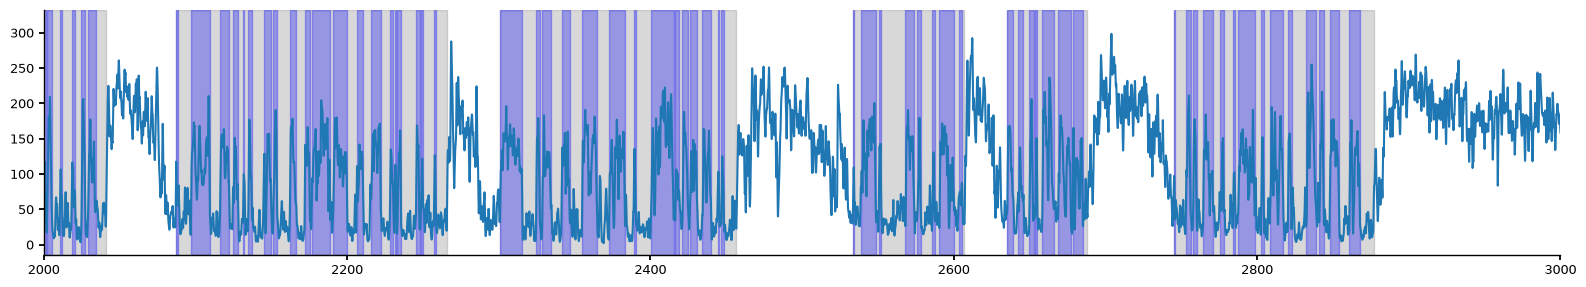

In [212]:
fig, ax = fma.plotting.makeFigure(size=(40,7))
ax[0].plot(firing.t,firing.sel(reg='nr'))
ax[0].set(xlim=[2000,3000])
fma.plotting.plotIntervals(isa)
fma.plotting.plotIntervals(on,color='blue')

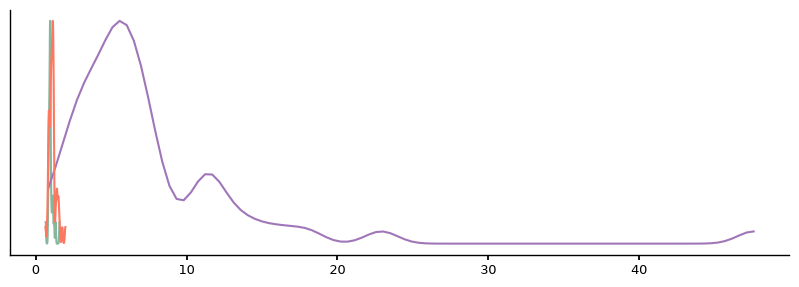

In [213]:
fig, ax = fma.plotting.makeFigure(size=(20,7))
for r in session_fr:
    fma.plotting.plotPDF(session_fr[r][:,1]/session_fr[r][:,2],bandwidth=0.15,n_points=100,norm='max',color=isru.paperColors(r));
#ax[0].set(ylabel='ON firing rate (Hz)',xlabel='OFF firing rate (Hz)');

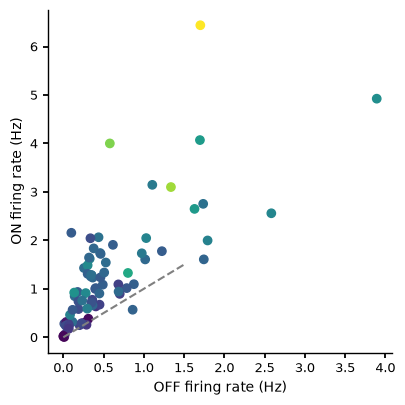

In [116]:
fig, ax = fma.plotting.makeFigure(size=(10,10))
ax[0].plot([0,1.5],[0,1.5],color='gray',ls='--')
ax[0].scatter(fr['nr'][:,2],fr['nr'][:,1],c=fr['nr'][:,0])
ax[0].set(ylabel='ON firing rate (Hz)',xlabel='OFF firing rate (Hz)');

In [190]:
regs = ['hpc','nr','pfc','th']
fr = fma.data.runBatch(batch_file,_ISAUnitFR,parallel=True)


Starting Batch, 2026-07-10 11:04:59.891813 

Batch completed with 0 errors, 2026-07-10 11:05:15.952457


In [195]:
fr_cat = {r: xr.concat([d[r] for d in fr if d is not None if r in d],dim='unit',join='outer') for r in regs}
#fr_cat_avg = fr_cat.groupby('rat').mean(dim='rat',skipna=True)

/tmp/ipykernel_1342633/2681711772.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  fr_cat = {r: xr.concat([d[r] for d in fr if d is not None if r in d],dim='unit',join='outer') for r in regs}
/tmp/ipykernel_1342633/2681711772.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  fr_cat = {r: xr.concat([d[r] for 

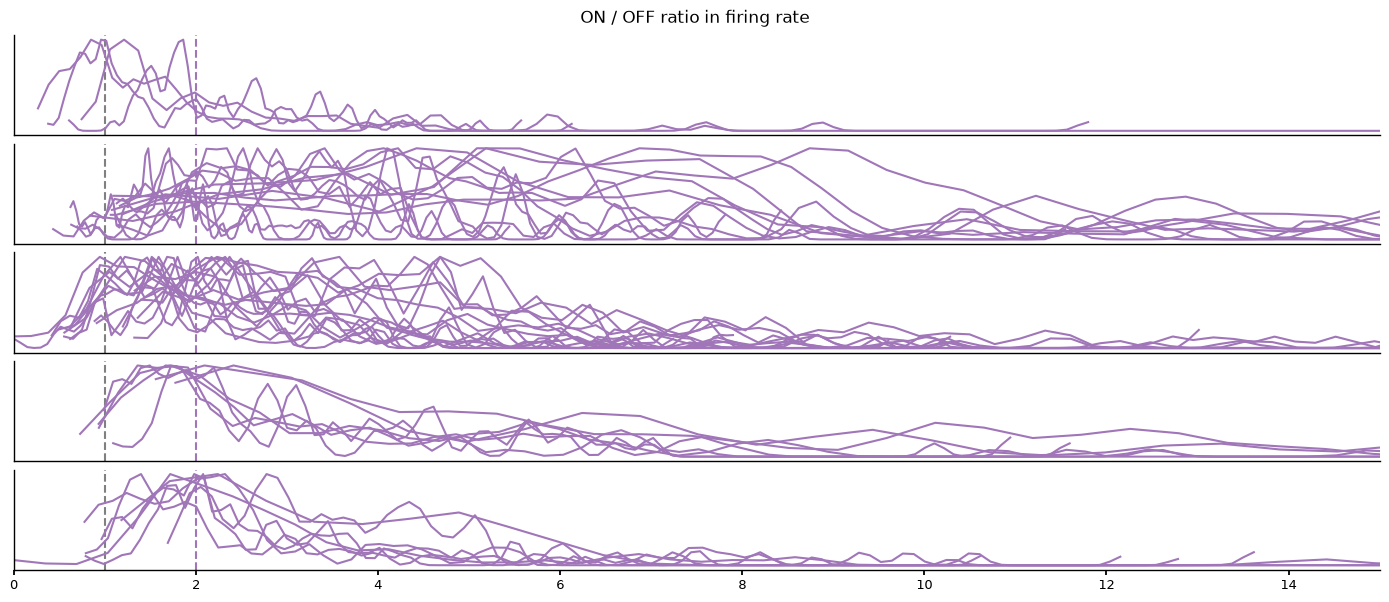

In [222]:
# per animal pdf
rat_unique = np.unique(fr_cat['nr'].rat)
fig, ax = fma.plotting.makeFigure('ON / OFF ratio in firing rate',(len(rat_unique),1),size=(35,15))

for i, rat in enumerate(rat_unique):
    ax[i].axvline(1,color='gray',ls='--')
    ax[i].axvline(2,color=isru.paperColors('nr'),ls='--')
    ax[i].set(xlim=[0,15])
for f in fr:
    if f is not None:
        for r in f:
            if r == 'nr':
                data = f[r][:,1] / f[r][:,2]
                fma.plotting.plotPDF(data[data<100],bandwidth=.05,n_points=100,norm='max',color=isru.paperColors(r),ax=ax[rat_unique==f[r].rat.values][0])

fma.plotting.setProp(ax[:-1],xticks=[])

/tmp/ipykernel_1342633/202603249.py:2: RuntimeWarning: All-NaN slice encountered
  med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])
/tmp/ipykernel_1342633/202603249.py:2: RuntimeWarning: All-NaN slice encountered
  med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])
/tmp/ipykernel_1342633/202603249.py:2: RuntimeWarning: All-NaN slice encountered
  med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])
/tmp/ipykernel_1342633/202603249.py:2: RuntimeWarning: All-NaN slice encountered
  med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])
/tmp/ipykernel_1342633/202603249.py:2: RuntimeWarning: All-NaN slice encountered
  med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])


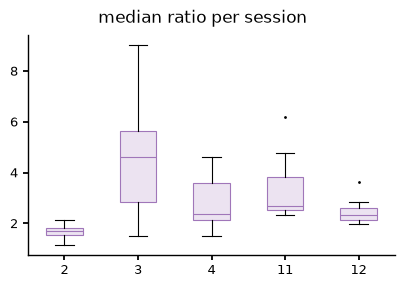

In [236]:
# median ratio per animal
med = np.array([np.nanmedian(f['nr'][:,1] / f['nr'][:,2]) for f in fr if f is not None])
rat = np.array([f['nr'].rat.values for f in fr if f is not None])
fig, ax = fma.plotting.makeFigure('median ratio per session',size=(10,7))
fma.plotting.boxPlot((med[rat==r] for r in rat_unique),color=isru.paperColors('nr'))
ax[0].set(xticklabels=rat_unique);

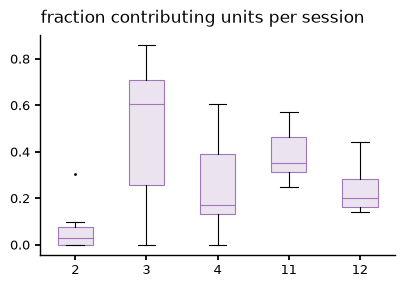

In [237]:
# super-threshold units
n_super = np.array([np.mean((f['nr'][:,1] / f['nr'][:,2]) > 4) for f in fr if f is not None])
rat = np.array([f['nr'].rat.values for f in fr if f is not None])
fig, ax = fma.plotting.makeFigure('fraction contributing units per session',size=(10,7))
fma.plotting.boxPlot((n_super[rat==r] for r in rat_unique),color=isru.paperColors('nr'))
ax[0].set(xticklabels=rat_unique);

/tmp/ipykernel_1342633/4144694843.py:11: RuntimeWarning: divide by zero encountered in divide
  fr_rat = fr_rat[:,1] / fr_rat[:,2]
/tmp/ipykernel_1342633/4144694843.py:11: RuntimeWarning: invalid value encountered in divide
  fr_rat = fr_rat[:,1] / fr_rat[:,2]


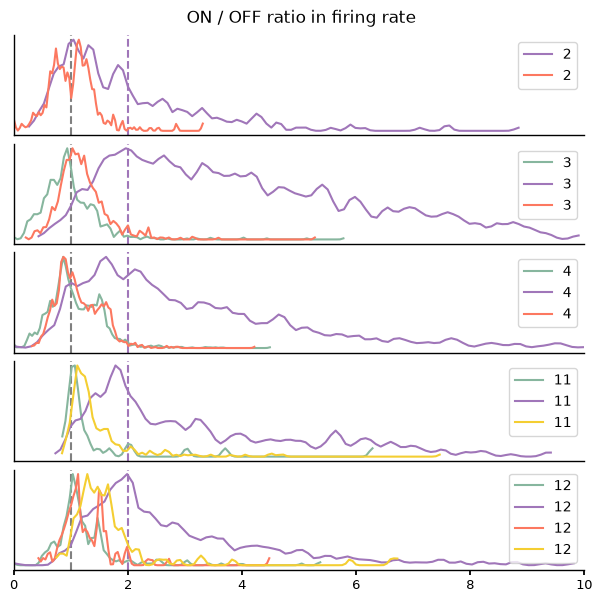

In [196]:
# per animal pdf
rat_unique = np.unique(fr_cat['nr'].rat)
fig, ax = fma.plotting.makeFigure('ON / OFF ratio in firing rate',(len(rat_unique),1),size=(15,15))

for i, rat in enumerate(rat_unique):
    ax[i].axvline(1,color='gray',ls='--')
    ax[i].axvline(2,color=isru.paperColors('nr'),ls='--')
    for r in fr_cat:
        if rat in fr_cat[r].rat:
            fr_rat = fr_cat[r].sel(rat=rat).values
            fr_rat = fr_rat[:,1] / fr_rat[:,2]
            fma.plotting.plotPDF(fr_rat[fr_rat < 10],bandwidth=.05,n_points=100,norm='max',color=isru.paperColors(r),label=rat,ax=ax[i])
            ax[i].legend(); ax[i].set(xlim=[0,10])
fma.plotting.setProp(ax[:-1],xticks=[])

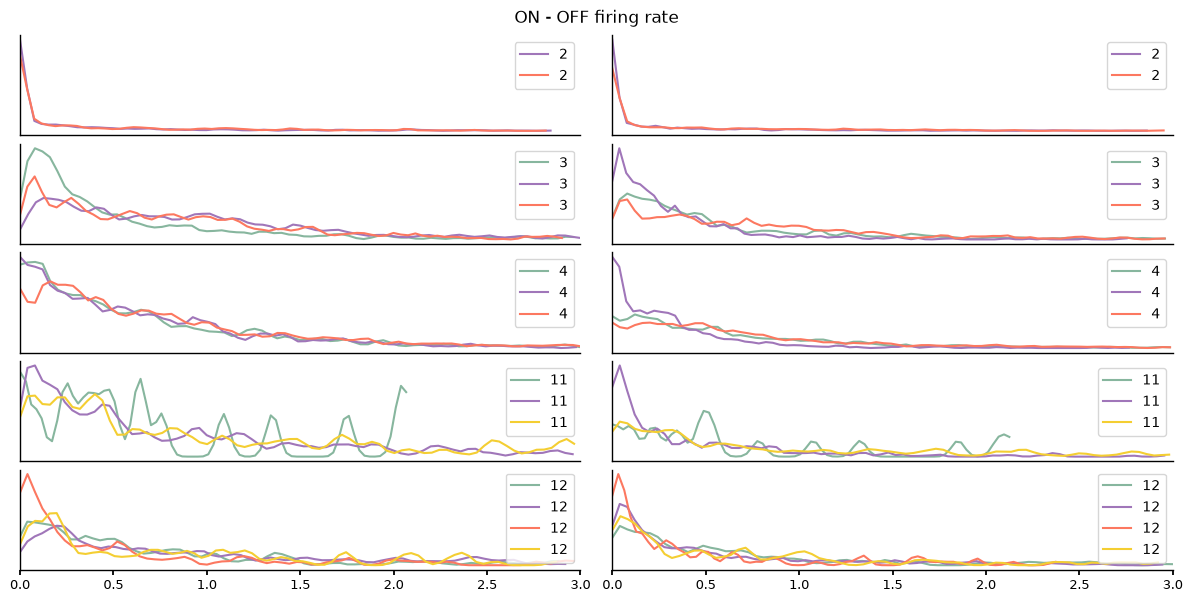

In [197]:
# per animal pdf
rat_unique = np.unique(fr_cat['nr'].rat)
fig, ax = fma.plotting.makeFigure('ON - OFF firing rate',(len(rat_unique),2),size=(30,15))

for i, rat in enumerate(rat_unique):
    for r in fr_cat:
        if rat in fr_cat[r].rat:
            fr_rat = fr_cat[r].sel(rat=rat).values
            for j in [0,1]:
                fr_r = fr_rat[:,j+1]
                fma.plotting.plotPDF(fr_r[fr_r < 3],bandwidth=.05,n_points=75,color=isru.paperColors(r),label=rat,ax=ax[i,j])
                ax[i,j].legend(); ax[i,j].set(xlim=[0,3])
fma.plotting.setProp(ax[:-1],xticks=[])